In [4]:
# 02_modelling.ipynb — cell 1
import sys
import os
sys.path.append(os.path.abspath(".."))


In [5]:
import importlib
import src.preprocessing as prep

importlib.reload(prep)

<module 'src.preprocessing' from 'c:\\Users\\IqraRafiq\\credit_risk_nl\\src\\preprocessing.py'>

In [12]:
from ucimlrepo import fetch_ucirepo
from src.preprocessing import preprocess

ds = fetch_ucirepo(id=144)
X  = ds.data.features
y  = ds.data.targets.iloc[:, 0]

X_train, X_test, y_train, y_test = preprocess(
    X, y,  # keep all for now, SHAP will confirm later
    save_artifacts=True,
)

Input X shape: (1000, 20)
Input X columns: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']
Input X head:
   Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A143        A152            2        A173            1   
1           22        A143        A152   

In [6]:
import sys
print(sys.executable)

c:\Users\IqraRafiq\credit_risk_nl\env\Scripts\python.exe


In [10]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import shap, joblib

In [13]:
# Baseline logistic regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

LR AUC: 0.8033333333333333


In [14]:
# XGBoost with imbalance handling
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    random_state=42,
    base_score=0.5
)


In [15]:
xgb_model.fit(X_train, y_train,
    eval_set=[(X_test, y_test)], verbose=False)
print("XGB AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

XGB AUC: 0.7911904761904761


In [16]:
explainer = shap.TreeExplainer(xgb_model)

In [31]:
shap_vals = explainer.shap_values(X_test)

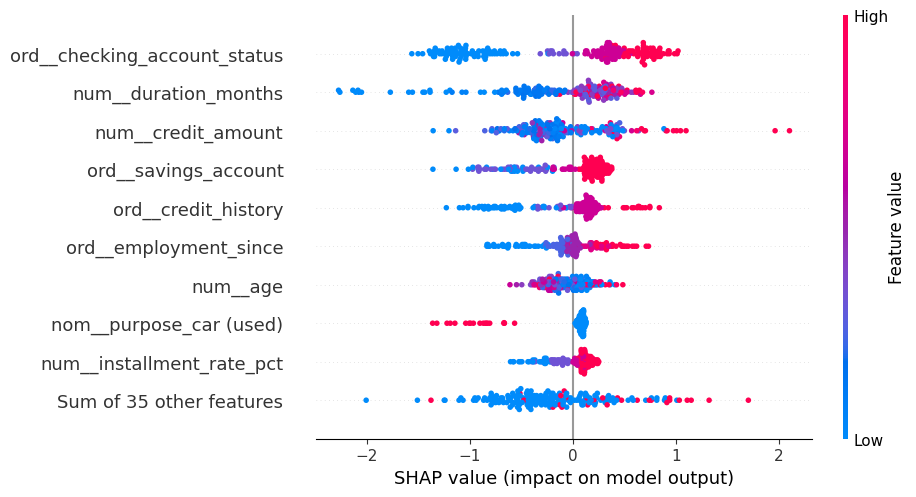

In [17]:
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)